In [1]:
#!pip install tensorflow
#!pip install matplotlib
#!pip install einops
#!pip install torch
#!pip install scikit-learn

In [2]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Details:", tf.config.list_physical_devices('GPU'))
print("Is Built with CUDA:", tf.test.is_built_with_cuda())


2025-06-27 13:49:20.408384: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-27 13:49:20.445106: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751003360.471303    3524 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751003360.477569    3524 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751003360.509786    3524 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Num GPUs Available: 1
GPU Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Is Built with CUDA: True


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0, EfficientNetV2B1, EfficientNetV2B2, EfficientNetV2B3
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.applications import EfficientNetB7, EfficientNetB5
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers.schedules import ExponentialDecay

In [4]:

# Set image size
IMG_SIZE = (224, 224)  # ResNet50 default input size
BATCH_SIZE = 16

# Load datasets from folders
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/mnt/c/Users/YapJack/Desktop/DeepEarthMY/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/mnt/c/Users/YapJack/Desktop/DeepEarthMY/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/mnt/c/Users/YapJack/Desktop/DeepEarthMY/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)


Found 3222 files belonging to 2 classes.


I0000 00:00:1751003367.860002    3524 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5441 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 701 files belonging to 2 classes.
Found 711 files belonging to 2 classes.


2025-06-27 13:49:38.274483: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-27 13:49:39.048699: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


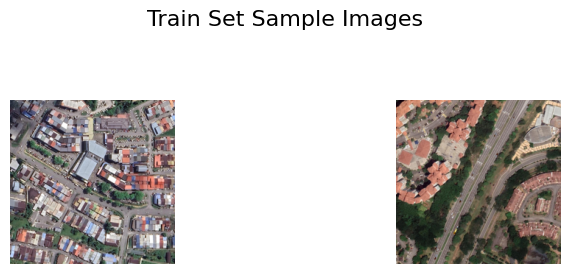

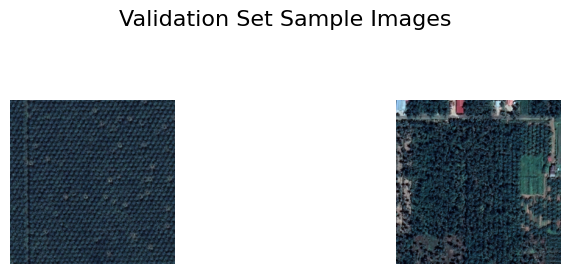

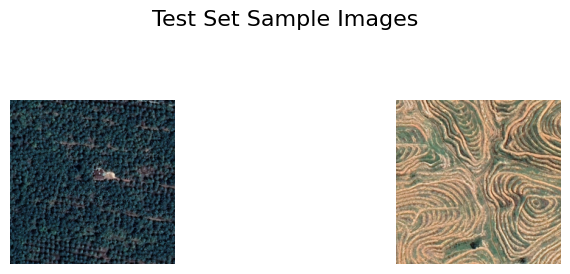

In [5]:
# Get class names from one of the datasets
class_names = train_dataset.class_names

def collect_images(dataset, class_names, num_images=2):
    """Collect a few sample images per class."""
    class_images = {class_name: [] for class_name in class_names}

    for images, labels in dataset:
        for img, lbl in zip(images, labels):
            class_index = tf.argmax(lbl).numpy()  # because of 'categorical' label_mode
            class_name = class_names[class_index]
            if len(class_images[class_name]) < num_images:
                class_images[class_name].append(img.numpy().astype("uint8"))
        if all(len(imgs) == num_images for imgs in class_images.values()):
            break
    return class_images

def visualize_dataset(class_images, title="Sample Images"):
    """Visualize the collected images."""
    num_classes = len(class_images)
    plt.figure(figsize=(8, num_classes * 2.5))
    for i, (class_name, imgs) in enumerate(class_images.items()):
        for j, img in enumerate(imgs):
            ax = plt.subplot(num_classes, 2, i * 2 + j + 1)
            plt.imshow(img)
            if j == 0:
                ax.set_ylabel(class_name, fontsize=12)
            plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(pad=2.0, rect=[0, 0.03, 1, 0.95])
    plt.show()

# Collect and visualize
train_images = collect_images(train_dataset, class_names, num_images=2)
val_images = collect_images(val_dataset, class_names, num_images=2)
test_images = collect_images(test_dataset, class_names, num_images=2)

visualize_dataset(train_images, title="Train Set Sample Images")
visualize_dataset(val_images, title="Validation Set Sample Images")
visualize_dataset(test_images, title="Test Set Sample Images")

# EfficientNetV2 B0

In [13]:
# Build the EfficientNetV2B0 model from scratch (no pretrained weights)
base_model0 = EfficientNetV2B0(
    include_top=False,       # Exclude final classification layer. Add own custom classification head later
    weights=None,            # <== THIS MEANS NO PRETRAINED WEIGHTS
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    pooling='avg'            # Global average pooling at the end
)

# Build the full model
model0 = keras.Sequential([
    base_model0,
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # change 6 to match your num_classes
])

# Learning rate decay schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,      # decay every 10k steps
    decay_rate=0.9,         # multiply LR by 0.9 every decay_steps
    staircase=True
)

# Compile the model
model0.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary (optional)
model0.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,709,841 (25.60 MB)

 Trainable params: 6,647,697 (25.36 MB)

 Non-trainable params: 62,144 (242.75 KB)

In [14]:
early_stopping_efficient = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True
)

checkpoint_efficient0 = keras.callbacks.ModelCheckpoint(
    'best_efficientNet0decay.keras',    # save best model to this file
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [15]:
history_efficient0 = model0.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint_efficient0, early_stopping_efficient]  # include your early stopping too
)

Epoch 1/100


I0000 00:00:1748800582.159064    1889 service.cc:152] XLA service 0x74563c0021b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748800582.159094    1889 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-06-02 01:56:22.857521: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748800585.956284    1889 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-06-02 01:56:28.265348: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24392', 4 bytes spill stores, 4 bytes spill loads

2025-06-02 01:56:28.444424: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24392_

200/202 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7204 - loss: 0.7244

2025-06-02 01:56:59.718326: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24392', 12 bytes spill stores, 12 bytes spill loads

2025-06-02 01:56:59.739829: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24392_0', 176 bytes spill stores, 524 bytes spill loads

2025-06-02 01:56:59.817608: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24392', 104 bytes spill stores, 104 bytes spill loads

2025-06-02 01:57:00.283146: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24392', 4760 bytes spill stores, 4760 bytes spill loads

2025-06-02 01:57:00.474150

202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7210 - loss: 0.7231

2025-06-02 01:57:22.417161: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2313', 104 bytes spill stores, 104 bytes spill loads

2025-06-02 01:57:22.455255: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2313_0', 176 bytes spill stores, 524 bytes spill loads

2025-06-02 01:57:22.487339: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2313', 12 bytes spill stores, 12 bytes spill loads

2025-06-02 01:57:22.980664: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2313', 5172 bytes spill stores, 5164 bytes spill loads

2025-06-02 01:57:22.988912: I 

202/202 ━━━━━━━━━━━━━━━━━━━━ 79s 193ms/step - accuracy: 0.7212 - loss: 0.7225 - val_accuracy: 0.8146 - val_loss: 0.5222
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.8258 - loss: 0.4203 - val_accuracy: 0.8573 - val_loss: 0.3039
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8973 - loss: 0.2678 - val_accuracy: 0.8031 - val_loss: 0.5134
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9096 - loss: 0.2319 - val_accuracy: 0.7846 - val_loss: 0.9717
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9151 - loss: 0.2185 - val_accuracy: 0.8787 - val_loss: 0.2892
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9254 - loss: 0.2081 - val_accuracy: 0.9301 - val_loss: 0.1984
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9249 - loss: 0.1953 - val_accuracy: 0.8060 - val_loss: 0.3755
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9247 - loss: 0.2091 - val_accura

In [6]:
best_model0 = keras.models.load_model('best_efficientNet0decay.keras')

In [7]:
test_loss, test_acc = best_model0.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

I0000 00:00:1751003383.293331   12131 service.cc:152] XLA service 0x72e8080557c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751003383.293373   12131 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-06-27 13:49:43.375155: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751003383.794148   12131 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-06-27 13:49:44.295451: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2313_0', 200 bytes spill stores, 536 bytes spill loads

2025-06-27 13:49:44.463327: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2

14/45 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8806 - loss: 0.3642

I0000 00:00:1751003388.772704   12131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/45 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8844 - loss: 0.3301

2025-06-27 13:49:50.415609: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2313_0', 176 bytes spill stores, 524 bytes spill loads

2025-06-27 13:49:50.419675: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2313', 12 bytes spill stores, 12 bytes spill loads

2025-06-27 13:49:50.531279: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2313', 104 bytes spill stores, 104 bytes spill loads

2025-06-27 13:49:51.041226: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2313', 4916 bytes spill stores, 4964 bytes spill loads

2025-06-27 13:49:51.216372: I 

45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.8846 - loss: 0.3263
Test accuracy: 0.8861, Test loss: 0.3007


In [8]:
# Reload test dataset with guaranteed ordering
test_dataset2 = tf.keras.preprocessing.image_dataset_from_directory(
    "/mnt/c/Users/YapJack/Desktop/DeepEarthMY/test",
    image_size=(224, 224),
    batch_size=16,
    label_mode='binary',
    shuffle=False
)

Found 711 files belonging to 2 classes.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf

def evaluate_model_binary(model, test_dataset2):
    """
    Evaluates a binary classification model on a given test dataset.

    Parameters:
    - model: Trained Keras model
    - test_dataset: A tf.data.Dataset (batched) with binary labels and shuffle=False

    Returns:
    - Dictionary with accuracy, precision, recall, and F1-score
    """
    # Extract true labels
    y_true = np.concatenate([y.numpy() for _, y in test_dataset2], axis=0).astype("int32").flatten()

    # Predict probabilities and threshold
    y_pred_probs = model.predict(test_dataset2)
    y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

    # Verify distributions
    print("True label distribution:", np.bincount(y_true))
    print("Predicted label distribution:", np.bincount(y_pred))

    # Compute metrics
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print results
    print(f"Manual Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


In [10]:
evaluate_model_binary(best_model0, test_dataset2)

2025-06-27 13:49:55.561956: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step
True label distribution: [402 309]
Predicted label distribution: [333 378]
Manual Accuracy: 0.8861
Precision: 0.8016
Recall: 0.9806
F1-score: 0.8821


{'accuracy': 0.8860759493670886,
 'precision': 0.8015873015873016,
 'recall': 0.9805825242718447,
 'f1_score': 0.8820960698689956}

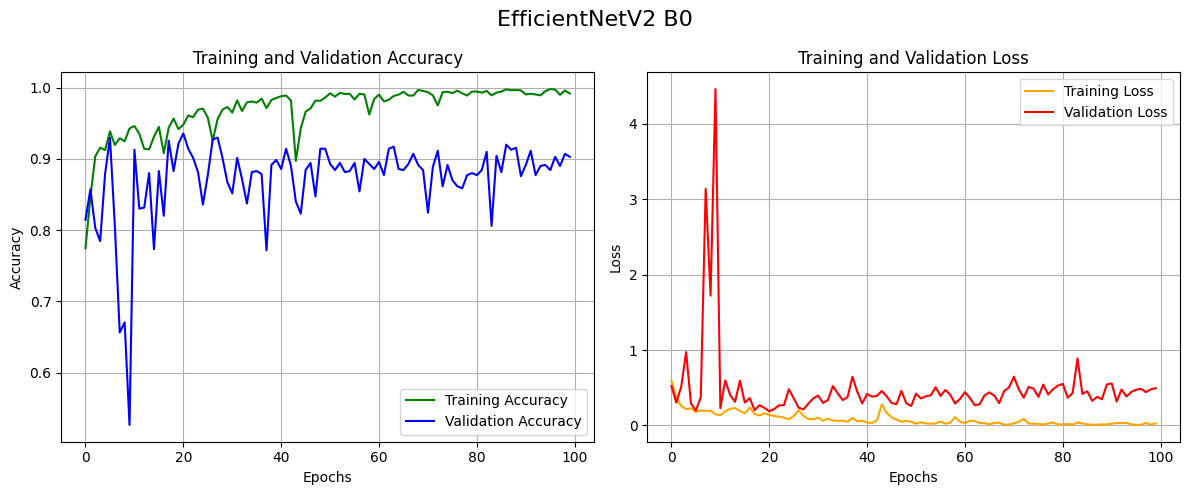

In [18]:
import matplotlib.pyplot as plt

# Extract required metrics
train_acc = history_efficient0.history['accuracy']
train_loss = history_efficient0.history['loss']
val_acc = history_efficient0.history['val_accuracy']
val_loss = history_efficient0.history['val_loss']
epochs_range = range(len(val_acc))

# Plotting
plt.figure(figsize=(12, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss', color='orange')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.suptitle('EfficientNetV2 B0', fontsize=16)
plt.tight_layout()
plt.show()


# EfficientNetV2 B1

In [19]:
# Build the EfficientNetV2B3 model from scratch (no pretrained weights)
base_model1 = EfficientNetV2B1(
    include_top=False,       # Exclude final classification layer. Add own custom classification head later
    weights=None,            # <== THIS MEANS NO PRETRAINED WEIGHTS
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    pooling='avg'            # Global average pooling at the end
)

# Build the full model
model1 = keras.Sequential([
    base_model1, # <== EfficientNetV2B3
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # change 6 to match your num_classes
])

# Learning rate decay schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,      # decay every 10k steps
    decay_rate=0.9,         # multiply LR by 0.9 every decay_steps
    staircase=True
)

# Compile the model
model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary (optional)
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b1 (Functional)  │ (None, 1280)           │     6,931,124 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,721,653 (29.46 MB)

 Trainable params: 7,649,045 (29.18 MB)

 Non-trainable params: 72,608 (283.62 KB)

In [20]:
early_stopping_efficient = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True
)

checkpoint_efficient1 = keras.callbacks.ModelCheckpoint(
    'best_efficientNet1decay.keras',    # save best model to this file
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [21]:
history_efficient1 = model1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint_efficient1, early_stopping_efficient]  # include your early stopping too
)

Epoch 1/100
200/202 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7136 - loss: 0.6804

2025-06-02 02:10:36.798977: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion', 684 bytes spill stores, 660 bytes spill loads



202/202 ━━━━━━━━━━━━━━━━━━━━ 77s 178ms/step - accuracy: 0.7142 - loss: 0.6789 - val_accuracy: 0.8188 - val_loss: 0.4537
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8372 - loss: 0.4044 - val_accuracy: 0.8160 - val_loss: 0.3393
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.8809 - loss: 0.2844 - val_accuracy: 0.9116 - val_loss: 0.2348
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9044 - loss: 0.2551 - val_accuracy: 0.7974 - val_loss: 0.3843
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8728 - loss: 0.3050 - val_accuracy: 0.8402 - val_loss: 0.3651
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8943 - loss: 0.2723 - val_accuracy: 0.8916 - val_loss: 0.3141
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9192 - loss: 0.2171 - val_accuracy: 0.9016 - val_loss: 0.2440
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.8399 - loss: 0.4053 - val_a

In [27]:
best_model1 = keras.models.load_model('best_efficientNet1decay.keras')

In [9]:
test_loss, test_acc = best_model1.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8636 - loss: 0.4940
Test accuracy: 0.8650, Test loss: 0.4623


In [28]:
evaluate_model_binary(best_model1, test_dataset2)

45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step
True label distribution: [402 309]
Predicted label distribution: [326 385]
Manual Accuracy: 0.8650
Precision: 0.7766
Recall: 0.9676
F1-score: 0.8617


{'accuracy': 0.8649789029535865,
 'precision': 0.7766233766233767,
 'recall': 0.9676375404530745,
 'f1_score': 0.861671469740634}

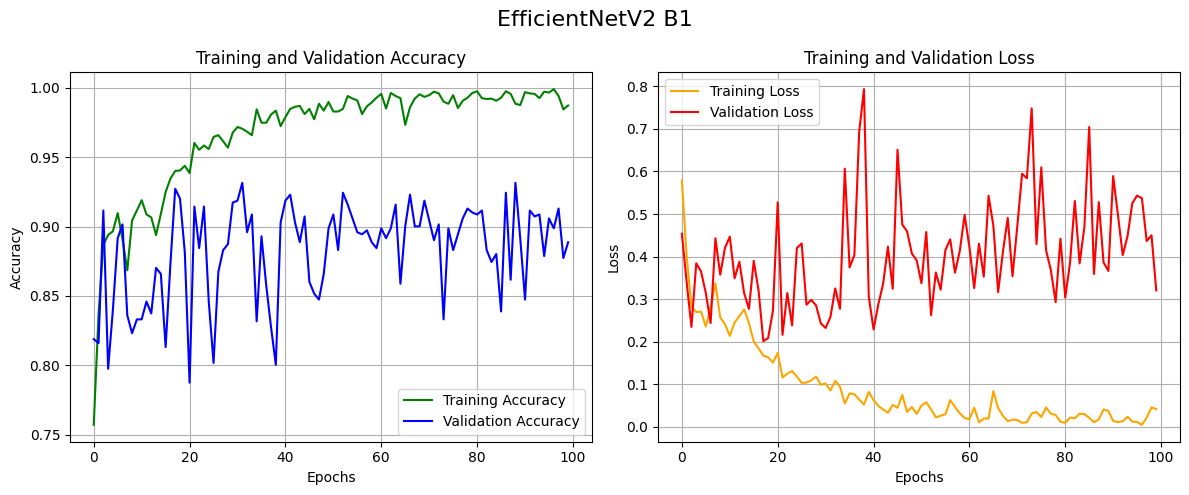

In [26]:
# Extract required metrics
train_acc = history_efficient1.history['accuracy']
train_loss = history_efficient1.history['loss']
val_acc = history_efficient1.history['val_accuracy']
val_loss = history_efficient1.history['val_loss']
epochs_range = range(len(val_acc))

# Plotting
plt.figure(figsize=(12, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss', color='orange')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.suptitle('EfficientNetV2 B1', fontsize=16)
plt.tight_layout()
plt.show()


# EfficientNetV2 B2

In [27]:
# Build the EfficientNetV2B3 model from scratch (no pretrained weights)
base_model2 = EfficientNetV2B2(
    include_top=False,       # Exclude final classification layer. Add own custom classification head later
    weights=None,            # <== THIS MEANS NO PRETRAINED WEIGHTS
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    pooling='avg'            # Global average pooling at the end
)

# Build the full model
model2 = keras.Sequential([
    base_model2, # <== EfficientNetV2B3
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # change 6 to match your num_classes
])

# Learning rate decay schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,      # decay every 10k steps
    decay_rate=0.9,         # multiply LR by 0.9 every decay_steps
    staircase=True
)

# Compile the model
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary (optional)
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b2 (Functional)  │ (None, 1408)           │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,625,439 (36.72 MB)

 Trainable params: 9,541,615 (36.40 MB)

 Non-trainable params: 83,824 (327.44 KB)

In [28]:
early_stopping_efficient = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True
)

checkpoint_efficient2 = keras.callbacks.ModelCheckpoint(
    'best_efficientNet2decay.keras',    # save best model to this file
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [29]:
history_efficient2 = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint_efficient2, early_stopping_efficient]  # include your early stopping too
)

Epoch 1/100


2025-06-02 02:36:46.220813: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 40 bytes spill stores, 40 bytes spill loads

2025-06-02 02:36:46.226843: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 264 bytes spill stores, 264 bytes spill loads

2025-06-02 02:36:46.245764: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 4 bytes spill stores, 4 bytes spill loads

2025-06-02 02:36:46.735302: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 40 bytes spill stores, 40 bytes spill loads

2025-06-02 02:36:46.792607: I extern

201/202 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6657 - loss: 0.7893

2025-06-02 02:37:25.362497: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 264 bytes spill stores, 264 bytes spill loads

2025-06-02 02:37:25.364494: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 12 bytes spill stores, 12 bytes spill loads

2025-06-02 02:37:25.372118: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 40 bytes spill stores, 40 bytes spill loads

2025-06-02 02:37:26.002042: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32015', 4552 bytes spill stores, 4532 bytes spill loads

2025-06-02 02:37:26.177435: I 

202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.6660 - loss: 0.7888

2025-06-02 02:37:53.270316: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 12 bytes spill stores, 12 bytes spill loads

2025-06-02 02:37:53.528374: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-02 02:37:53.641004: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 264 bytes spill stores, 264 bytes spill loads

2025-06-02 02:37:53.668793: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-02 02:37:53.935155: I external

202/202 ━━━━━━━━━━━━━━━━━━━━ 112s 292ms/step - accuracy: 0.6662 - loss: 0.7882 - val_accuracy: 0.8260 - val_loss: 0.4924
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.8015 - loss: 0.4792 - val_accuracy: 0.8274 - val_loss: 0.4176
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.8671 - loss: 0.3490 - val_accuracy: 0.8459 - val_loss: 0.3019
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.8937 - loss: 0.2694 - val_accuracy: 0.9016 - val_loss: 0.2348
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9115 - loss: 0.2465 - val_accuracy: 0.8716 - val_loss: 0.3035
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.8981 - loss: 0.2576 - val_accuracy: 0.8902 - val_loss: 0.2472
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.8778 - loss: 0.3054 - val_accuracy: 0.8602 - val_loss: 0.3037
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9044 - loss: 0.2492 - va

In [25]:
best_model2 = keras.models.load_model('best_efficientNet2decay.keras')

In [11]:
test_loss, test_acc = best_model2.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

2025-06-07 15:40:16.602577: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-07 15:40:16.633211: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 264 bytes spill stores, 264 bytes spill loads

2025-06-07 15:40:16.634550: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 4 bytes spill stores, 4 bytes spill loads

2025-06-07 15:40:16.646271: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-07 15:40:16.649708: I external/l

41/45 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9049 - loss: 0.6319

2025-06-07 15:40:21.216322: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 12 bytes spill stores, 12 bytes spill loads

2025-06-07 15:40:21.409836: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 264 bytes spill stores, 264 bytes spill loads

2025-06-07 15:40:21.469319: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-07 15:40:21.511336: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2934', 40 bytes spill stores, 40 bytes spill loads

2025-06-07 15:40:21.751187: I external

45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.9055 - loss: 0.6302
Test accuracy: 0.9100, Test loss: 0.6098


In [26]:
evaluate_model_binary(best_model2, test_dataset2)

2025-06-21 14:38:55.931853: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-21 14:38:57.995285: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2928', 4 bytes spill stores, 4 bytes spill loads

2025-06-21 14:38:58.035969: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2928', 40 bytes spill stores, 40 bytes spill loads

2025-06-21 14:38:58.092745: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2928', 264 bytes spill stores, 264 bytes spill loads

2025-06-21 14:38:58.093283: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Regist

41/45 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

2025-06-21 14:39:04.033822: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2928', 12 bytes spill stores, 12 bytes spill loads

2025-06-21 14:39:04.258458: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2928', 264 bytes spill stores, 264 bytes spill loads

2025-06-21 14:39:04.301644: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2928', 40 bytes spill stores, 40 bytes spill loads

2025-06-21 14:39:04.336693: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2928', 40 bytes spill stores, 40 bytes spill loads

2025-06-21 14:39:04.587253: I external

45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step
True label distribution: [402 309]
Predicted label distribution: [350 361]
Manual Accuracy: 0.9100
Precision: 0.8393
Recall: 0.9806
F1-score: 0.9045


{'accuracy': 0.909985935302391,
 'precision': 0.8393351800554016,
 'recall': 0.9805825242718447,
 'f1_score': 0.9044776119402985}

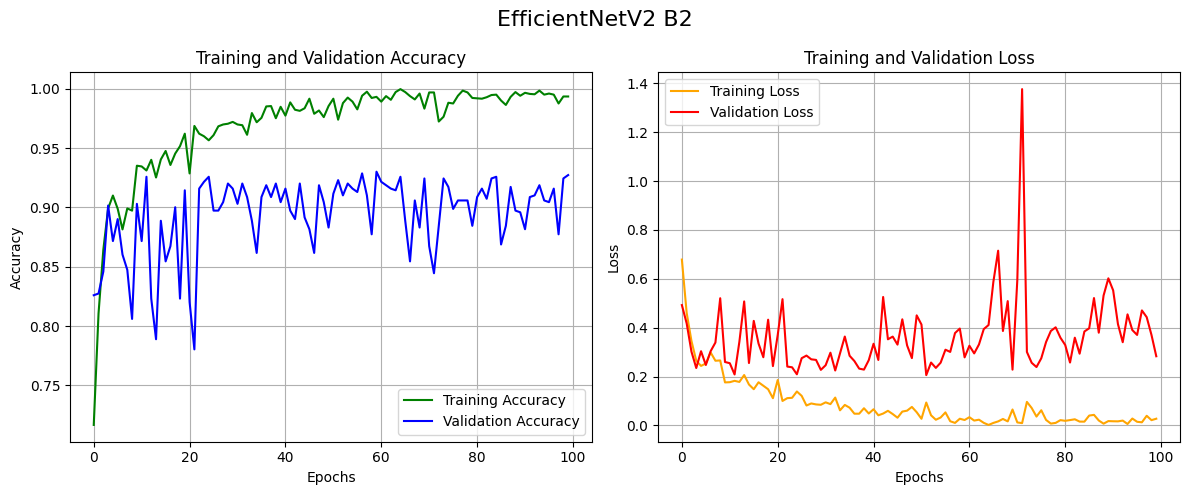

In [35]:
# Extract required metrics
train_acc = history_efficient2.history['accuracy']
train_loss = history_efficient2.history['loss']
val_acc = history_efficient2.history['val_accuracy']
val_loss = history_efficient2.history['val_loss']
epochs_range = range(len(val_acc))

# Plotting
plt.figure(figsize=(12, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss', color='orange')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.suptitle('EfficientNetV2 B2', fontsize=16)
plt.tight_layout()
plt.show()


# EfficientNetV2 B3

In [5]:
# Build the EfficientNetV2B3 model from scratch (no pretrained weights)
base_model = EfficientNetV2B3(
    include_top=False,       # Exclude final classification layer. Add own custom classification head later
    weights=None,            # <== THIS MEANS NO PRETRAINED WEIGHTS
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    pooling='avg'            # Global average pooling at the end
)

# Build the full model
model = keras.Sequential([
    base_model, # <== EfficientNetV2B3
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # change 6 to match your num_classes
])

# Learning rate decay schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,      # decay every 10k steps
    decay_rate=0.9,         # multiply LR by 0.9 every decay_steps
    staircase=True
)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary (optional)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b3 (Functional)  │ (None, 1536)           │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,852,223 (52.84 MB)

 Trainable params: 13,741,471 (52.42 MB)

 Non-trainable params: 110,752 (432.62 KB)

In [6]:
early_stopping_efficient = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True
)

checkpoint_efficient = keras.callbacks.ModelCheckpoint(
    'best_efficientNetdecay.keras',    # save best model to this file
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [7]:
history_efficient = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint_efficient, early_stopping_efficient]  # include your early stopping too
)

Epoch 1/100


I0000 00:00:1748806195.443974     894 service.cc:152] XLA service 0x7eac7c0440f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748806195.444012     894 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-06-02 03:29:56.571138: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748806201.221355     894 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-06-02 03:30:05.034815: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37239', 4 bytes spill stores, 4 bytes spill loads

2025-06-02 03:30:05.280904: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37239'

201/202 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7086 - loss: 0.7026

2025-06-02 03:30:50.591184: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37239', 12 bytes spill stores, 12 bytes spill loads

2025-06-02 03:30:50.701299: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37239', 104 bytes spill stores, 104 bytes spill loads

2025-06-02 03:30:51.106828: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37239', 4028 bytes spill stores, 4020 bytes spill loads

2025-06-02 03:30:51.388356: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37239', 4044 bytes spill stores, 4024 bytes spill loads

2025-06-02 03:31:14.929608

202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7088 - loss: 0.7020

2025-06-02 03:31:20.441405: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3422', 12 bytes spill stores, 12 bytes spill loads

2025-06-02 03:31:20.511566: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3422', 104 bytes spill stores, 104 bytes spill loads

2025-06-02 03:31:20.733190: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3422', 4032 bytes spill stores, 4012 bytes spill loads

2025-06-02 03:31:20.799512: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3422', 1008 bytes spill stores, 1008 bytes spill loads



202/202 ━━━━━━━━━━━━━━━━━━━━ 110s 269ms/step - accuracy: 0.7090 - loss: 0.7015 - val_accuracy: 0.8160 - val_loss: 0.3552
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.8389 - loss: 0.4019 - val_accuracy: 0.8702 - val_loss: 1.2317
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.7705 - loss: 0.5084 - val_accuracy: 0.9030 - val_loss: 0.2893
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.7069 - loss: 0.6271 - val_accuracy: 0.8916 - val_loss: 0.2992
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.8040 - loss: 0.4423 - val_accuracy: 0.8131 - val_loss: 0.4267
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.8619 - loss: 0.3271 - val_accuracy: 0.8745 - val_loss: 0.3179
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.8187 - loss: 0.4107 - val_accuracy: 0.8702 - val_loss: 0.6561
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.8954 - loss: 0.2512 - va

In [29]:
best_model = keras.models.load_model('best_efficientNet.keras')

In [16]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b3 (Functional)  │ (None, 1536)           │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,335,167 (157.68 MB)

 Trainable params: 13,741,471 (52.42 MB)

 Non-trainable params: 110,752 (432.62 KB)

 Optimizer params: 27,482,944 (104.84 MB)

In [18]:
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9138 - loss: 0.2771
Test accuracy: 0.9001, Test loss: 0.3455


In [31]:
evaluate_model_binary(best_model, test_dataset2)

2025-06-21 14:43:32.007116: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3416_0', 200 bytes spill stores, 656 bytes spill loads

2025-06-21 14:43:32.065577: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3416', 4 bytes spill stores, 4 bytes spill loads

2025-06-21 14:43:32.112905: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3416', 116 bytes spill stores, 116 bytes spill loads

2025-06-21 14:43:32.330504: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3416', 3940 bytes spill stores, 3920 bytes spill loads

2025-06-21 14:43:32.369095: I ex

43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

2025-06-21 14:43:38.821302: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3416', 12 bytes spill stores, 12 bytes spill loads

2025-06-21 14:43:38.839934: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3416', 104 bytes spill stores, 104 bytes spill loads

2025-06-21 14:43:39.177288: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3416', 4084 bytes spill stores, 4064 bytes spill loads

2025-06-21 14:43:39.195299: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3416', 4020 bytes spill stores, 4012 bytes spill loads



45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step
True label distribution: [402 309]
Predicted label distribution: [353 358]
Manual Accuracy: 0.9001
Precision: 0.8324
Recall: 0.9644
F1-score: 0.8936


{'accuracy': 0.90014064697609,
 'precision': 0.8324022346368715,
 'recall': 0.9644012944983819,
 'f1_score': 0.8935532233883059}

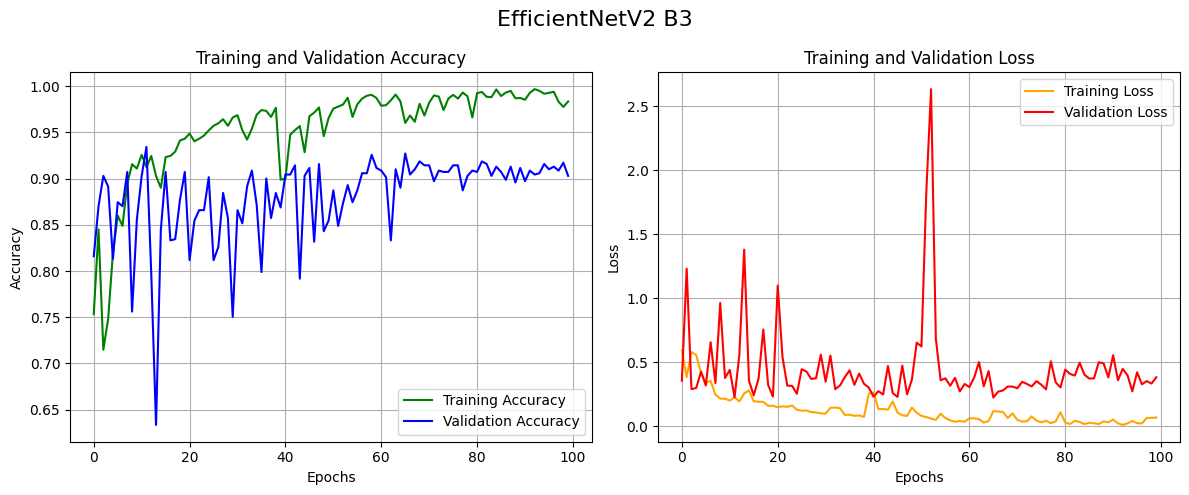

In [11]:
# Extract required metrics
train_acc = history_efficient.history['accuracy']
train_loss = history_efficient.history['loss']
val_acc = history_efficient.history['val_accuracy']
val_loss = history_efficient.history['val_loss']
epochs_range = range(len(val_acc))

# Plotting
plt.figure(figsize=(12, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss', color='orange')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.suptitle('EfficientNetV2 B3', fontsize=16)
plt.tight_layout()
plt.show()


# EfficientNetV2 B5

In [7]:
# Build the EfficientNetB5 model from scratch (no pretrained weights)
base_model5 = EfficientNetB5(
    include_top=False,       # Exclude final classification layer. Add own custom classification head later
    weights=None,            # <== THIS MEANS NO PRETRAINED WEIGHTS
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    pooling='avg'            # Global average pooling at the end
)

# Build the full model
model5 = keras.Sequential([
    base_model5,
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # change 6 to match your num_classes
])

# Learning rate decay schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,      # decay every 10k steps
    decay_rate=0.9,         # multiply LR by 0.9 every decay_steps
    staircase=True
)

# Compile the model
model5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary (optional)
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb5 (Functional)     │ (None, 2048)           │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,697,272 (113.29 MB)

 Trainable params: 29,522,993 (112.62 MB)

 Non-trainable params: 174,279 (680.78 KB)

In [8]:
early_stopping_efficient5 = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True
)

checkpoint_efficient5 = keras.callbacks.ModelCheckpoint(
    'best_efficientNet5decay.keras',    # save best model to this file
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [9]:
history_efficient5 = model5.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint_efficient5, early_stopping_efficient5]  # include your early stopping too
)

Epoch 1/100


I0000 00:00:1748837396.685494   31458 service.cc:152] XLA service 0x70307c05ccd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748837396.685523   31458 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-06-02 12:09:58.114835: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748837404.362939   31458 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-06-02 12:10:09.364396: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_54350', 4 bytes spill stores, 4 bytes spill loads

2025-06-02 12:10:09.684218: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_54350'

201/202 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7254 - loss: 0.6786

2025-06-02 12:11:23.243353: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_54350', 12 bytes spill stores, 12 bytes spill loads

2025-06-02 12:11:23.358831: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_54350', 104 bytes spill stores, 104 bytes spill loads

2025-06-02 12:11:23.792747: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_54350', 4020 bytes spill stores, 4000 bytes spill loads

2025-06-02 12:11:23.967727: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_54350', 4028 bytes spill stores, 4020 bytes spill loads

2025-06-02 12:11:54.802370

202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.7254 - loss: 0.6783

2025-06-02 12:12:03.350227: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 12 bytes spill stores, 12 bytes spill loads

2025-06-02 12:12:03.609578: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 104 bytes spill stores, 104 bytes spill loads

2025-06-02 12:12:03.814404: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 1008 bytes spill stores, 1008 bytes spill loads

2025-06-02 12:12:03.919703: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 4032 bytes spill stores, 4012 bytes spill loads



202/202 ━━━━━━━━━━━━━━━━━━━━ 163s 426ms/step - accuracy: 0.7255 - loss: 0.6780 - val_accuracy: 0.5549 - val_loss: 6.1024
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - accuracy: 0.7699 - loss: 0.5234 - val_accuracy: 0.5549 - val_loss: 3.5337
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 32s 160ms/step - accuracy: 0.8392 - loss: 0.3851 - val_accuracy: 0.8374 - val_loss: 0.4556
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 31s 151ms/step - accuracy: 0.8196 - loss: 0.4726 - val_accuracy: 0.8117 - val_loss: 1.2516
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - accuracy: 0.8581 - loss: 0.3567 - val_accuracy: 0.8117 - val_loss: 0.7636
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - accuracy: 0.9112 - loss: 0.2525 - val_accuracy: 0.8074 - val_loss: 1.2770
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - accuracy: 0.8935 - loss: 0.2402 - val_accuracy: 0.8374 - val_loss: 0.4006
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 32s 160ms/step - accuracy: 0.8980 - loss: 0.25

In [33]:
best_model5 = keras.models.load_model('best_efficientNet5decay.keras')

In [20]:
best_model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb5 (Functional)     │ (None, 2048)           │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,743,259 (338.53 MB)

 Trainable params: 29,522,993 (112.62 MB)

 Non-trainable params: 174,279 (680.78 KB)

 Optimizer params: 59,045,987 (225.24 MB)

In [21]:
test_loss, test_acc = best_model5.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

2025-06-07 15:44:51.661626: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 4 bytes spill stores, 4 bytes spill loads

2025-06-07 15:44:51.790760: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 116 bytes spill stores, 116 bytes spill loads

2025-06-07 15:44:52.153903: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 992 bytes spill stores, 992 bytes spill loads

2025-06-07 15:44:52.246286: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 3964 bytes spill stores, 3944 bytes spill loads



43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8615 - loss: 0.5630

2025-06-07 15:44:59.906096: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 12 bytes spill stores, 12 bytes spill loads

2025-06-07 15:45:00.251073: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 104 bytes spill stores, 104 bytes spill loads

2025-06-07 15:45:00.445937: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 4084 bytes spill stores, 4064 bytes spill loads

2025-06-07 15:45:00.528543: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4807', 4020 bytes spill stores, 4012 bytes spill loads



45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.8612 - loss: 0.5656
Test accuracy: 0.8579, Test loss: 0.6007


In [34]:
evaluate_model_binary(best_model5, test_dataset2)

2025-06-21 14:45:27.396775: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4801', 4 bytes spill stores, 4 bytes spill loads

2025-06-21 14:45:27.571157: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4801', 116 bytes spill stores, 116 bytes spill loads

2025-06-21 14:45:27.768582: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4801', 3964 bytes spill stores, 3944 bytes spill loads

2025-06-21 14:45:27.823733: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4801', 992 bytes spill stores, 992 bytes spill loads



43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

2025-06-21 14:45:37.442396: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4801', 12 bytes spill stores, 12 bytes spill loads

2025-06-21 14:45:37.715402: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4801', 104 bytes spill stores, 104 bytes spill loads

2025-06-21 14:45:38.028205: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4801', 4020 bytes spill stores, 4012 bytes spill loads

2025-06-21 14:45:38.122690: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4801', 4084 bytes spill stores, 4064 bytes spill loads



45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 214ms/step
True label distribution: [402 309]
Predicted label distribution: [317 394]
Manual Accuracy: 0.8579
Precision: 0.7640
Recall: 0.9741
F1-score: 0.8563


{'accuracy': 0.8579465541490858,
 'precision': 0.7639593908629442,
 'recall': 0.9741100323624595,
 'f1_score': 0.8563300142247511}

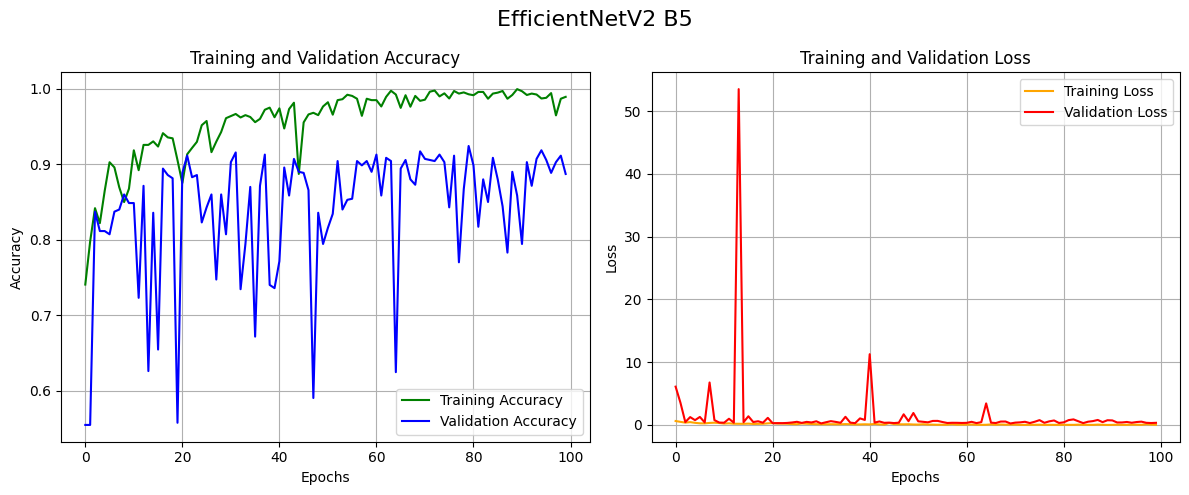

In [13]:
# Extract required metrics
train_acc = history_efficient5.history['accuracy']
train_loss = history_efficient5.history['loss']
val_acc = history_efficient5.history['val_accuracy']
val_loss = history_efficient5.history['val_loss']
epochs_range = range(len(val_acc))

# Plotting
plt.figure(figsize=(12, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss', color='orange')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.suptitle('EfficientNetV2 B5', fontsize=16)
plt.tight_layout()
plt.show()


# EfficientNetV2 B7

In [5]:
# Build the EfficientNetB5 model from scratch (no pretrained weights)
base_model7 = EfficientNetB7(
    include_top=False,       # Exclude final classification layer. Add own custom classification head later
    weights=None,            # <== THIS MEANS NO PRETRAINED WEIGHTS
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    pooling='avg'            # Global average pooling at the end
)

# Build the full model
model = keras.Sequential([
    base_model7,
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # change 6 to match your num_classes
])

# Learning rate decay schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,      # decay every 10k steps
    decay_rate=0.9,         # multiply LR by 0.9 every decay_steps
    staircase=True
)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary (optional)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb7 (Functional)     │ (None, 2560)           │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,543,576 (250.03 MB)

 Trainable params: 65,231,313 (248.84 MB)

 Non-trainable params: 312,263 (1.19 MB)

In [6]:
early_stopping_efficient7 = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True
)

checkpoint_efficient7 = keras.callbacks.ModelCheckpoint(
    'best_efficientNet7decay.keras',    # save best model to this file
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [7]:
history_efficient7 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint_efficient7, early_stopping_efficient7]  # include your early stopping too
)

Epoch 1/100


I0000 00:00:1749191524.506378    1699 service.cc:152] XLA service 0x7a4ad007f780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749191524.506414    1699 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-06-06 14:32:06.453932: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749191534.813892    1699 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-06-06 14:32:22.286648: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77303', 4 bytes spill stores, 4 bytes spill loads

2025-06-06 14:32:22.553948: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77303'

201/202 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.6721 - loss: 0.7761

2025-06-06 14:34:15.739638: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77303', 12 bytes spill stores, 12 bytes spill loads

2025-06-06 14:34:15.841510: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77303', 104 bytes spill stores, 104 bytes spill loads

2025-06-06 14:34:16.134510: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77303', 4044 bytes spill stores, 4024 bytes spill loads

2025-06-06 14:34:16.645646: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77303', 4028 bytes spill stores, 4020 bytes spill loads



202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.6722 - loss: 0.7757

2025-06-06 14:35:08.991729: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 12 bytes spill stores, 12 bytes spill loads

2025-06-06 14:35:09.042211: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 104 bytes spill stores, 104 bytes spill loads

2025-06-06 14:35:09.234397: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731_0', 36 bytes spill stores, 36 bytes spill loads

2025-06-06 14:35:09.390147: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 4032 bytes spill stores, 4012 bytes spill loads

2025-06-06 14:35:09.462585: I ex

202/202 ━━━━━━━━━━━━━━━━━━━━ 237s 653ms/step - accuracy: 0.6723 - loss: 0.7754 - val_accuracy: 0.4451 - val_loss: 5.1627
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 57s 282ms/step - accuracy: 0.7558 - loss: 0.5869 - val_accuracy: 0.5549 - val_loss: 6.0374
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 58s 287ms/step - accuracy: 0.7585 - loss: 0.5526 - val_accuracy: 0.5835 - val_loss: 1.6192
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 58s 289ms/step - accuracy: 0.7905 - loss: 0.4754 - val_accuracy: 0.8374 - val_loss: 0.4623
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 55s 272ms/step - accuracy: 0.8081 - loss: 0.4464 - val_accuracy: 0.4151 - val_loss: 12.1350
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 54s 266ms/step - accuracy: 0.8132 - loss: 0.4555 - val_accuracy: 0.5649 - val_loss: 7.6058
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 58s 286ms/step - accuracy: 0.8377 - loss: 0.3846 - val_accuracy: 0.9258 - val_loss: 0.2093
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 55s 272ms/step - accuracy: 0.8933 - loss: 0.2

In [35]:
best_model = keras.models.load_model('best_efficientNet7decay.keras')

In [23]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb7 (Functional)     │ (None, 2560)           │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,006,203 (747.70 MB)

 Trainable params: 65,231,313 (248.84 MB)

 Non-trainable params: 312,263 (1.19 MB)

 Optimizer params: 130,462,627 (497.68 MB)

In [24]:
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

2025-06-07 15:45:36.881399: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 4 bytes spill stores, 4 bytes spill loads

2025-06-07 15:45:37.130214: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 116 bytes spill stores, 116 bytes spill loads

2025-06-07 15:45:37.419650: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 992 bytes spill stores, 992 bytes spill loads

2025-06-07 15:45:37.458035: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 3940 bytes spill stores, 3920 bytes spill loads



44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9072 - loss: 0.5181

2025-06-07 15:45:47.733944: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 12 bytes spill stores, 12 bytes spill loads

2025-06-07 15:45:48.084005: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 104 bytes spill stores, 104 bytes spill loads

2025-06-07 15:45:48.382084: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 4020 bytes spill stores, 4012 bytes spill loads

2025-06-07 15:45:48.430994: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6731', 4084 bytes spill stores, 4064 bytes spill loads



45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - accuracy: 0.9071 - loss: 0.5216
Test accuracy: 0.9058, Test loss: 0.5985


In [37]:
evaluate_model_binary(best_model, test_dataset2)

2025-06-21 14:47:06.348663: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6725', 4 bytes spill stores, 4 bytes spill loads

2025-06-21 14:47:06.561210: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6725', 116 bytes spill stores, 116 bytes spill loads

2025-06-21 14:47:06.859851: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6725', 3940 bytes spill stores, 3920 bytes spill loads

2025-06-21 14:47:06.931081: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6725', 992 bytes spill stores, 992 bytes spill loads



44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

2025-06-21 14:47:19.634773: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6725', 12 bytes spill stores, 12 bytes spill loads

2025-06-21 14:47:19.875998: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6725', 104 bytes spill stores, 104 bytes spill loads

2025-06-21 14:47:20.216664: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6725', 4020 bytes spill stores, 4012 bytes spill loads

2025-06-21 14:47:20.230194: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6725', 4084 bytes spill stores, 4064 bytes spill loads



45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 281ms/step
True label distribution: [402 309]
Predicted label distribution: [345 366]
Manual Accuracy: 0.9058
Precision: 0.8306
Recall: 0.9838
F1-score: 0.9007


{'accuracy': 0.9057665260196905,
 'precision': 0.8306010928961749,
 'recall': 0.9838187702265372,
 'f1_score': 0.9007407407407407}

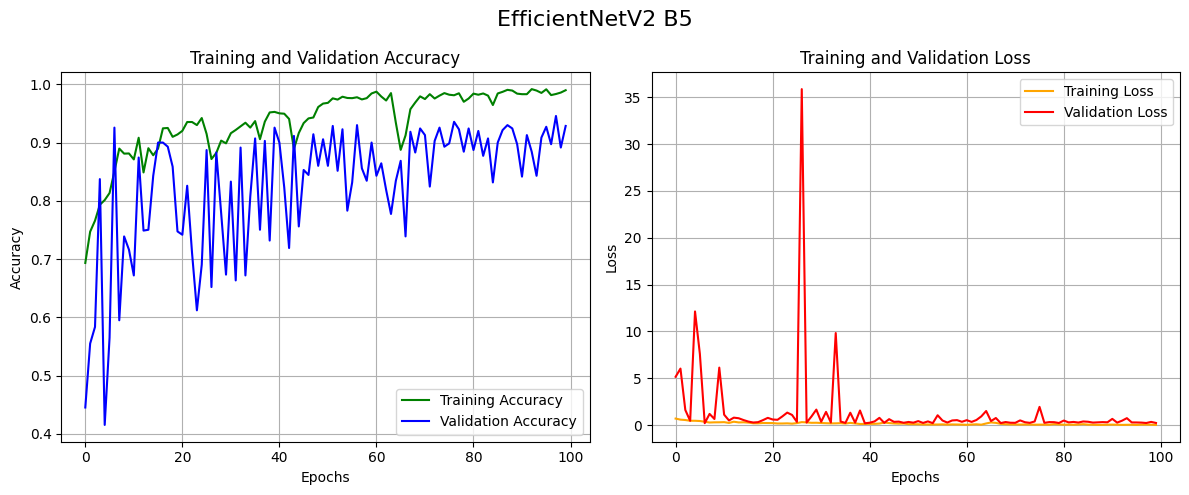

In [12]:
# Extract required metrics
train_acc = history_efficient7.history['accuracy']
train_loss = history_efficient7.history['loss']
val_acc = history_efficient7.history['val_accuracy']
val_loss = history_efficient7.history['val_loss']
epochs_range = range(len(val_acc))

# Plotting
plt.figure(figsize=(12, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss', color='orange')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.suptitle('EfficientNetV2 B5', fontsize=16)
plt.tight_layout()
plt.show()


# AlexNet

In [28]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
# import metric
from keras.metrics import categorical_crossentropy
# optimization method 
from keras.optimizers import SGD

In [29]:
def Alexnet():
  # Initialize the model
  model = Sequential()

  # layer 1: convolutional layer + max-pooling layer
  model.add(Conv2D(filters = 96, kernel_size = (11,11), strides= 4, padding = 'valid', activation='relu', input_shape = (224,224,3)))
  model.add(MaxPooling2D(pool_size = (3,3), strides = 2))

  # layer 2: convolutional layer + max-pooling layer 
  model.add(Conv2D(filters = 256, kernel_size = (5,5), padding = 'same', activation = 'relu'))
  model.add(MaxPooling2D(pool_size = (3,3), strides = 2))

  # layers 3-5: three convolutional layers + 1 max-pooling layer
  model.add(Conv2D(filters = 384, kernel_size = (3,3), padding = 'same', activation = 'relu'))
  model.add(Conv2D(filters = 384, kernel_size = (3,3), padding = 'same', activation = 'relu'))
  model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = 'same', activation = 'relu'))
  model.add(MaxPooling2D(pool_size = (3,3), strides = 2))

  # layers 6 - 8: two fully connected hidden layers and one fully connected output layer
  model.add(Flatten())
  model.add(Dense(4096, activation = 'relu'))
  model.add(Dropout(0.5))
  model.add(Dense(4096, activation = 'relu'))
  model.add(Dropout(0.5))
  model.add(Dense(1, activation = 'sigmoid'))

  # compile the model with a loss funciton, a metric and and optimizer method for estimating the loss function
  opt = SGD(learning_rate = 0.001)
  model.compile(loss = 'binary_crossentropy',
                optimizer = opt,
                metrics = ['accuracy'])

  return model

In [30]:
early_stopping_alex = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True
)

checkpoint_best_alex = keras.callbacks.ModelCheckpoint(
    'best_alex.keras',    # save best model to this file
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [31]:
model2 = Alexnet()

history = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint_best_alex, early_stopping_alex]  # include your early stopping too
)

Epoch 1/100


/home/yapjack/miniconda3/envs/fyp-py310/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


202/202 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.5038 - loss: 3.2353 - val_accuracy: 0.5164 - val_loss: 0.6728
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5816 - loss: 0.6694 - val_accuracy: 0.5121 - val_loss: 0.6676
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6689 - loss: 0.6694 - val_accuracy: 0.7090 - val_loss: 0.6269
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7039 - loss: 0.6476 - val_accuracy: 0.6662 - val_loss: 0.5740
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7199 - loss: 0.6310 - val_accuracy: 0.7304 - val_loss: 0.6446
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7257 - loss: 0.6266 - val_accuracy: 0.8302 - val_loss: 0.5338
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7320 - loss: 0.6075 - val_accuracy: 0.8431 - val_loss: 0.5323
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7623 - loss: 0.5753 - val_accuracy

In [40]:
best_alex = keras.models.load_model('best_alex.keras')

test_loss2, test_acc2 = best_alex.evaluate(test_dataset)
print(f"Test accuracy: {test_acc2:.4f}, Test loss: {test_loss2:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7644 - loss: 0.5018
Test accuracy: 0.7792, Test loss: 0.4691


In [39]:
evaluate_model_binary(best_alex, test_dataset2)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
True label distribution: [402 309]
Predicted label distribution: [335 376]
Manual Accuracy: 0.7792
Precision: 0.7021
Recall: 0.8544
F1-score: 0.7708


{'accuracy': 0.7791842475386779,
 'precision': 0.7021276595744681,
 'recall': 0.8543689320388349,
 'f1_score': 0.7708029197080292}

# Vit Transformer

In [48]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [49]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from random import random
from torchvision.transforms import Resize, ToTensor, Compose
from torchvision.transforms.functional import to_pil_image
import torch.optim as optim
import torch.nn as nn
import os

In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [51]:
# Define transform (resize, center crop, convert to tensor, normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # or (256, 256) if you want
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # standard ImageNet mean
                         std=[0.229, 0.224, 0.225])   # standard ImageNet std
])

In [52]:
# Dataset
train_path = "/mnt/c/Users/YapJack/Desktop/DeepEarthMY/train"
train_dataset = ImageFolder(root=train_path, transform=transform)

val_path = "/mnt/c/Users/YapJack/Desktop/DeepEarthMY/val"
val_dataset = ImageFolder(root=val_path, transform=transform)

test_path = "/mnt/c/Users/YapJack/Desktop/DeepEarthMY/test"
test_dataset = ImageFolder(root=test_path, transform=transform)

In [53]:
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_path: str, 
    val_path: str, 
    test_path: str, 
    transform: transforms.Compose, 
    batch_size: int, 
    num_workers: int=NUM_WORKERS
):

  # Use ImageFolder to create dataset(s)
  train_data = datasets.ImageFolder(train_path, transform=transform)
  val_data = datasets.ImageFolder(val_path, transform=transform)
  test_data = datasets.ImageFolder(test_path, transform=transform)
    
  # Get class names
  class_names = train_data.classes

  # Turn images into data loaders
  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True,
  )
  val_dataloader = DataLoader(
      val_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True,
  )

  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True,
  )

  return train_dataloader, val_dataloader, test_dataloader, class_names

In [54]:
# Create image size
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])           
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [55]:

# Set the batch size
BATCH_SIZE = 16

# Create data loaders
train_dataloader, val_dataloader, test_dataloader, class_names = create_dataloaders(
    train_path=train_path,
    val_path=val_path,
    test_path=test_path,
    transform=manual_transforms, 
    batch_size=BATCH_SIZE
)

train_dataloader, val_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x745a94929000>,
 ['Rural', 'Urban'])

torch.Size([3, 224, 224]) tensor(0)


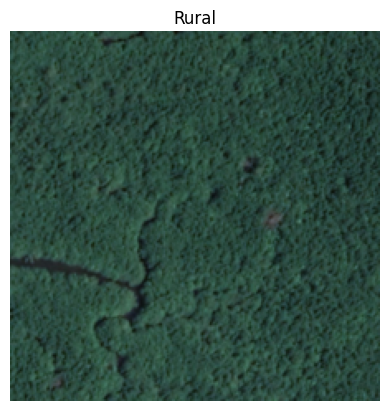

In [56]:
# Let's visualize a image in order to know if data is loaded properly or not

# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
print(image.shape, label)

# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

In [59]:
# 1. Create a class which subclasses nn.Module
class PatchEmbedding(nn.Module):
    """Turns a 2D input image into a 1D sequence learnable embedding vector.
    
    Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
    """ 
    # 2. Initialize the class with appropriate variables
    def __init__(self, 
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()
        
        # 3. Create a layer to turn an image into patches
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        # 4. Create a layer to flatten the patch feature maps into a single dimension
        self.flatten = nn.Flatten(start_dim=2, # only flatten the feature map dimensions into a single vector
                                  end_dim=3)

    # 5. Define the forward method 
    def forward(self, x):
        # Create assertion to check that inputs are the correct shape
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"Input image size must be divisble by patch size, image shape: {image_resolution}, patch size: {patch_size}"
        
        # Perform the forward pass
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched) 
        
        # 6. Make sure the output shape has the right order 
        return x_flattened.permute(0, 2, 1) # adjust so the embedding is on the final dimension [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]

In [60]:
# Let's test it on single image
patch_size =16

# Set seeds
def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)
    
    
    
set_seeds()

# Create an instance of patch embedding layer
patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

# Pass a single image through
print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension on the 0th index, otherwise will error
print(f"Output patch embedding shape: {patch_embedded_image.shape}")

Input image shape: torch.Size([1, 3, 224, 224])
Output patch embedding shape: torch.Size([1, 196, 768])


In [61]:
# View the patch embedding and patch embedding shape


print(patch_embedded_image) 
print(f"Patch embedding shape: {patch_embedded_image.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[-0.2393,  0.1099, -0.1332,  ...,  0.2293, -0.1048,  0.0783],
         [-0.2374,  0.0906, -0.1291,  ...,  0.2134, -0.0926,  0.1013],
         [-0.2370,  0.1300, -0.1323,  ...,  0.2256, -0.1274,  0.0816],
         ...,
         [-0.2772,  0.0909, -0.1144,  ...,  0.2394, -0.1138,  0.0506],
         [-0.2247,  0.1330, -0.0952,  ...,  0.1899, -0.1094,  0.0944],
         [-0.2143,  0.0881, -0.1146,  ...,  0.1974, -0.1265,  0.0625]]],
       grad_fn=<PermuteBackward0>)
Patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [62]:
# Now add the the learnable class embedding and position embeddings
# From start to positional encoding: All in 1 cell

set_seeds()

# 1. Set patch size
patch_size = 16

# 2. Print shape of original image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Get image tensor and add batch dimension
x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

# 4. Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

# 5. Pass image through patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")



# 6. Create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True) # make sure it's learnable
print(f"Class token embedding shape: {class_token.shape}")

# 7. Prepend class token embedding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")

# 8. Create position embedding
number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True) # make sure it's learnable


# 9. Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")
#patch_and_position_embedding

print(patch_embedding_class_token)  #1 is added in the beginning of each

Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimension shape: torch.Size([1, 3, 224, 224])
Patching embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])
tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.2393,  0.1099, -0.1332,  ...,  0.2293, -0.1048,  0.0783],
         [-0.2374,  0.0906, -0.1291,  ...,  0.2134, -0.0926,  0.1013],
         ...,
         [-0.2772,  0.0909, -0.1144,  ...,  0.2394, -0.1138,  0.0506],
         [-0.2247,  0.1330, -0.0952,  ...,  0.1899, -0.1094,  0.0944],
         [-0.2143,  0.0881, -0.1146,  ...,  0.1974, -0.1265,  0.0625]]],
       grad_fn=<CatBackward0>)


In [63]:
# 1. Create a class that inherits from nn.Module
class MultiheadSelfAttentionBlock(nn.Module):
    """Creates a multi-head self-attention block ("MSA block" for short).
    """
    # 2. Initialize the class with hyperparameters from Table 1
    def __init__(self,
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 attn_dropout:float=0): # doesn't look like the paper uses any dropout in MSABlocks
        super().__init__()
        
        # 3. Create the Norm layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        
        # 4. Create the Multi-Head Attention (MSA) layer
        self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                    num_heads=num_heads,
                                                    dropout=attn_dropout,
                                                    batch_first=True) # does our batch dimension come first?
        
    # 5. Create a forward() method to pass the data throguh the layers
    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(query=x, # query embeddings 
                                             key=x, # key embeddings
                                             value=x, # value embeddings
                                             need_weights=False) # do we need the weights or just the layer outputs?
        return attn_output

In [64]:
# 1. Create a class that inherits from nn.Module
class MLPBlock(nn.Module):
    """Creates a layer normalized multilayer perceptron block ("MLP block" for short)."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 embedding_dim:int=768, # Hidden Size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 dropout:float=0.1): # Dropout from Table 3 for ViT-Base
        super().__init__()
        
        # 3. Create the Norm layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        
        # 4. Create the Multilayer perceptron (MLP) layer(s)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(), # "The MLP contains two layers with a GELU non-linearity (section 3.1)."
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, # needs to take same in_features as out_features of layer above
                      out_features=embedding_dim), # take back to embedding_dim
            nn.Dropout(p=dropout) # "Dropout, when used, is applied after every dense layer.."
        )
    
    # 5. Create a forward() method to pass the data throguh the layers
    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x

In [65]:
# 1. Create a class that inherits from nn.Module
class TransformerEncoderBlock(nn.Module):
    """Creates a Transformer Encoder block."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 mlp_dropout:float=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                 attn_dropout:float=0): # Amount of dropout for attention layers
        super().__init__()

        # 3. Create MSA block (equation 2)
        self.msa_block = MultiheadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                     num_heads=num_heads,
                                                     attn_dropout=attn_dropout)
        
        # 4. Create MLP block (equation 3)
        self.mlp_block =  MLPBlock(embedding_dim=embedding_dim,
                                   mlp_size=mlp_size,
                                   dropout=mlp_dropout)
        
    # 5. Create a forward() method  
    def forward(self, x):
        
        # 6. Create residual connection for MSA block (add the input to the output)
        x =  self.msa_block(x) + x 
        
        # 7. Create residual connection for MLP block (add the input to the output)
        x = self.mlp_block(x) + x 
        
        return x
    

In [66]:
transformer_encoder_block = TransformerEncoderBlock()

from torchinfo import summary
# # Print an input and output summary of our Transformer Encoder (uncomment for full output)
summary(model=transformer_encoder_block,
        input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
       row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiheadSelfAttentionBlock (msa_block)          [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

In [67]:
# 1. Create a ViT class that inherits from nn.Module
class ViT(nn.Module):
    """Creates a Vision Transformer architecture with ViT-Base hyperparameters by default."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 img_size:int=224, # Training resolution from Table 3 in ViT paper
                 in_channels:int=3, # Number of channels in input image
                 patch_size:int=16, # Patch size
                 num_transformer_layers:int=12, # Layers from Table 1 for ViT-Base
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 attn_dropout:float=0, # Dropout for attention projection
                 mlp_dropout:float=0.1, # Dropout for dense/MLP layers 
                 embedding_dropout:float=0.1, # Dropout for patch and position embeddings
                 num_classes:int=1000): # Default for ImageNet but can customize this
        super().__init__() # don't forget the super().__init__()!
        
        # 3. Make the image size is divisble by the patch size 
        assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."
        
        # 4. Calculate number of patches (height * width/patch^2)
        self.num_patches = (img_size * img_size) // patch_size**2
                 
        # 5. Create learnable class embedding (needs to go at front of sequence of patch embeddings)
        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                            requires_grad=True)
        
        # 6. Create learnable position embedding
        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim),
                                               requires_grad=True)
                
        # 7. Create embedding dropout value
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)
        
        # 8. Create patch embedding layer
        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              embedding_dim=embedding_dim)
        
        # 9. Create Transformer Encoder blocks (we can stack Transformer Encoder blocks using nn.Sequential()) 
        # Note: The "*" means "all"
        self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                            num_heads=num_heads,
                                                                            mlp_size=mlp_size,
                                                                            mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])
       
        # 10. Create classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim, 
                      out_features=num_classes)
        )
    
    # 11. Create a forward() method
    def forward(self, x):
        
        # 12. Get batch size
        batch_size = x.shape[0]
        
        # 13. Create class token embedding and expand it to match the batch size (equation 1)
        class_token = self.class_embedding.expand(batch_size, -1, -1) # "-1" means to infer the dimension (try this line on its own)

        # 14. Create patch embedding (equation 1)
        x = self.patch_embedding(x)

        # 15. Concat class embedding and patch embedding (equation 1)
        x = torch.cat((class_token, x), dim=1)

        # 16. Add position embedding to patch embedding (equation 1) 
        x = self.position_embedding + x

        # 17. Run embedding dropout (Appendix B.1)
        x = self.embedding_dropout(x)

        # 18. Pass patch, position and class embedding through transformer encoder layers (equations 2 & 3)
        x = self.transformer_encoder(x)

        # 19. Put 0 index logit through classifier (equation 4)
        x = self.classifier(x[:, 0]) # run on each sample in a batch at 0 index

        return x       

In [68]:
# Train our MOdel

# Create an instance of ViT with the number of classes we're working with (pizza, steak, sushi)
vit = ViT(num_classes=len(class_names))

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

# Assume:
# vit = your ViT model instance (already created)
# train_dataloader, val_dataloader, test_dataloader = DataLoaders for train/val/test
# device = 'cuda' or 'cpu'
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.AdamW(vit.parameters(), lr=0.001)

optimizer = optim.AdamW(vit.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs = 100
best_val_accuracy = 0.0
best_vit_path = 'best_vit_model.pth'

vit.to(device)

for epoch in range(num_epochs):
    vit.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = vit(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataloader.dataset)
    epoch_train_accuracy = correct_train / total_train

    # Validation phase
    vit.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = vit(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataloader.dataset)
    epoch_val_accuracy = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

    # Save the best model
    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        torch.save(vit.state_dict(), best_vit_path)
        print(f"Best model saved with val accuracy: {best_val_accuracy:.4f}")

print("Training complete.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

# Load best model and evaluate on test set
vit.load_state_dict(torch.load(best_vit_path))
vit.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = vit(images)
        loss = criterion(outputs, labels)
        running_test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_loss = running_test_loss / len(test_dataloader.dataset)
test_accuracy = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch [1/100] Train Loss: 0.5138, Train Acc: 0.7349 | Val Loss: 0.4111, Val Acc: 0.8245
Best model saved with val accuracy: 0.8245
Epoch [2/100] Train Loss: 0.5178, Train Acc: 0.7197 | Val Loss: 0.4111, Val Acc: 0.8103
Epoch [3/100] Train Loss: 0.5162, Train Acc: 0.7325 | Val Loss: 0.4483, Val Acc: 0.7760
Epoch [4/100] Train Loss: 0.4958, Train Acc: 0.7322 | Val Loss: 0.3718, Val Acc: 0.8402
Best model saved with val accuracy: 0.8402
Epoch [5/100] Train Loss: 0.5003, Train Acc: 0.7436 | Val Loss: 0.4386, Val Acc: 0.8260
Epoch [6/100] Train Loss: 0.5159, Train Acc: 0.7266 | Val Loss: 0.3936, Val Acc: 0.8117
Epoch [7/100] Train Loss: 0.4928, Train Acc: 0.7396 | Val Loss: 0.4020, Val Acc: 0.8445
Best model saved with val accuracy: 0.8445
Epoch [8/100] Train Loss: 0.4963, Train Acc: 0.7412 | Val Loss: 0.3745, Val Acc: 0.8174
Epoch [9/100] Train Loss: 0.4901, Train Acc: 0.7529 | Val Loss: 0.3982, Val Acc: 0.8074
Epoch [10/100] Train Loss: 0.5019, Train Acc: 0.7343 | Val Loss: 0.4209, Val Ac

In [70]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collect predictions and labels
all_preds = []
all_labels = []

# Load best model
vit.load_state_dict(torch.load('best_vit_model.pth'))
vit.to(device)

vit.eval()

with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vit(inputs)  # shape: (batch_size, 2)
        _, predicted = torch.max(outputs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# Compute additional metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary')
recall = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Optional: display TP, TN, FP, FN if binary classification
if cm.shape == (2, 2):
    TN, FP, FN, TP = cm.ravel()
    print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
else:
    print("Not a binary classification problem.")


Confusion Matrix:
[[306  96]
 [ 55 254]]
Accuracy : 0.7876
Precision: 0.7257
Recall   : 0.8220
F1-score : 0.7709
TP: 254, TN: 306, FP: 96, FN: 55
